In [3]:
import pandas as pd


In [4]:
df = pd.read_csv(r"C:\Users\himan\OneDrive\Apps\Desktop\Customer Lifetime Value & Retention Strategy for a Premium Credit Card Company\archive (5)\BankChurners.csv")


In [5]:
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                            str
Customer_Age                                                                                                                            int64
Gender                                                                                                                                    str
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                           str
Marital_Status                                                                                                                            str
Income

In [8]:
df = df.drop(columns=[
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

In [9]:
print(df.columns.tolist())

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [10]:
df.to_csv("BankChurners_Cleaned.csv", index=False)

In [11]:
df["Age_Group"] = pd.cut(
    df["Customer_Age"],
    bins=[17, 30, 50, 100],
    labels=["Young", "Adult", "Senior"]
)

In [12]:
df["Customer_Status"] = df["Attrition_Flag"].replace({
    "Existing Customer": "Active",
    "Attrited Customer": "Attrited"
})

In [13]:
df["Spending_Category"] = pd.qcut(
    df["Total_Trans_Amt"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [14]:
df["Utilization_Category"] = pd.cut(
    df["Avg_Utilization_Ratio"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [15]:
df.to_csv("BankChurners_Cleaned_v2.csv", index=False)

In [16]:
import pandas as pd
from sqlalchemy import create_engine


In [17]:
df = pd.read_csv('BankChurners_Cleaned_v2.csv')

In [18]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Connection settings
USER = "root"
PASSWORD = "12345"
HOST = "127.0.0.1"
PORT = "3306"
DATABASE = "bank_db"

# 2. Connect to MySQL server and ensure the database exists
server_engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/")
with server_engine.connect() as conn:
    conn.execute(f"CREATE DATABASE IF NOT EXISTS {DATABASE};")

# 3. Create engine connected directly to 'bank_db'
db_engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

# 4. Read your CSV file
df = pd.read_csv("BankChurners_Cleaned_v2.csv")

# 5. Export to MySQL table
table_name = "bank_churners"
df.to_sql(name=table_name, con=db_engine, if_exists="replace", index=False)

print(f"Successfully loaded {len(df)} rows into table '{table_name}' inside '{DATABASE}'!")

ObjectNotExecutableError: Not an executable object: 'CREATE DATABASE IF NOT EXISTS bank_db;'

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# 1. Connection settings
USER = "root"
PASSWORD = "12345"
HOST = "127.0.0.1"
PORT = "3306"
DATABASE = "bank_db"

# 2. Connect to MySQL server and ensure the database exists
server_engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/")
with server_engine.connect() as conn:
    # Wrap the SQL string with text()
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {DATABASE};"))
    conn.commit()  # Explicit commit for database creation in SQLAlchemy 2.0

# 3. Create engine connected directly to 'bank_db'
db_engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

# 4. Read your CSV file
df = pd.read_csv("BankChurners_Cleaned_v2.csv")

# 5. Export to MySQL table
table_name = "bank_churners"
df.to_sql(name=table_name, con=db_engine, if_exists="replace", index=False)

print(f"Successfully loaded {len(df)} rows into table '{table_name}' inside '{DATABASE}'!")

Successfully loaded 10127 rows into table 'bank_churners' inside 'bank_db'!


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

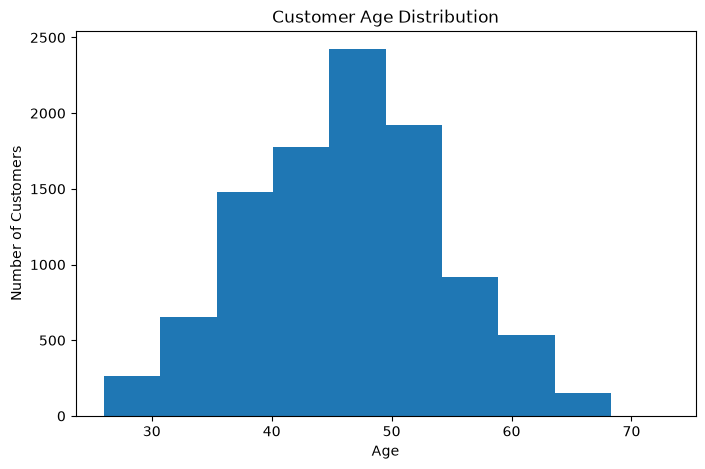

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df['Customer_Age'], bins=10)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

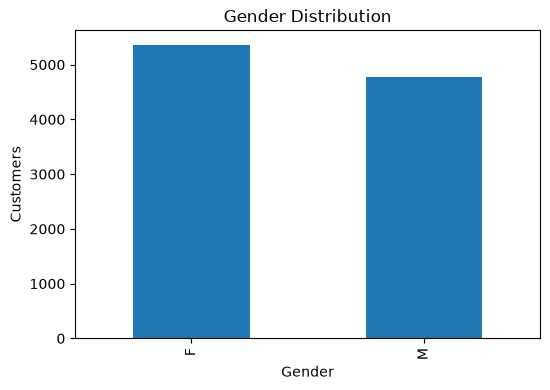

In [22]:
df['Gender'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Customers')
plt.show()

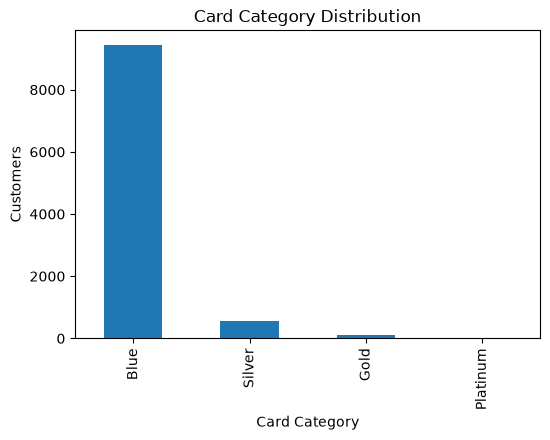

In [23]:
df['Card_Category'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title('Card Category Distribution')
plt.xlabel('Card Category')
plt.ylabel('Customers')
plt.show()

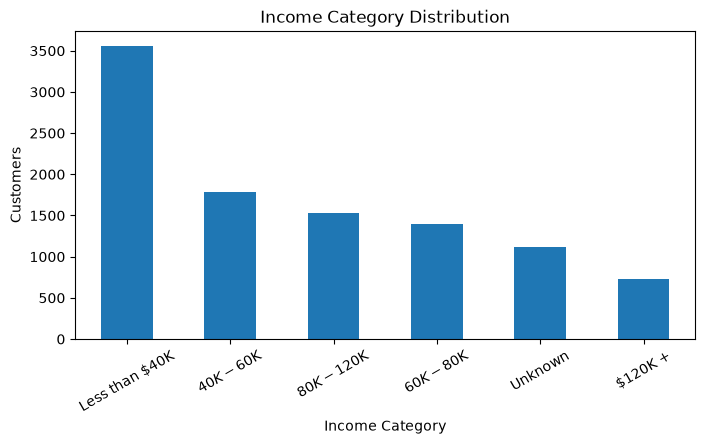

In [24]:
df['Income_Category'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title('Income Category Distribution')
plt.xlabel('Income Category')
plt.ylabel('Customers')
plt.xticks(rotation=30)
plt.show()

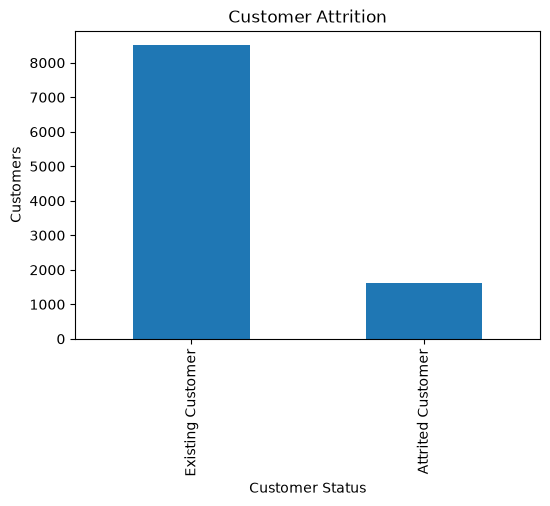

In [25]:
df['Attrition_Flag'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title('Customer Attrition')
plt.xlabel('Customer Status')
plt.ylabel('Customers')
plt.show()

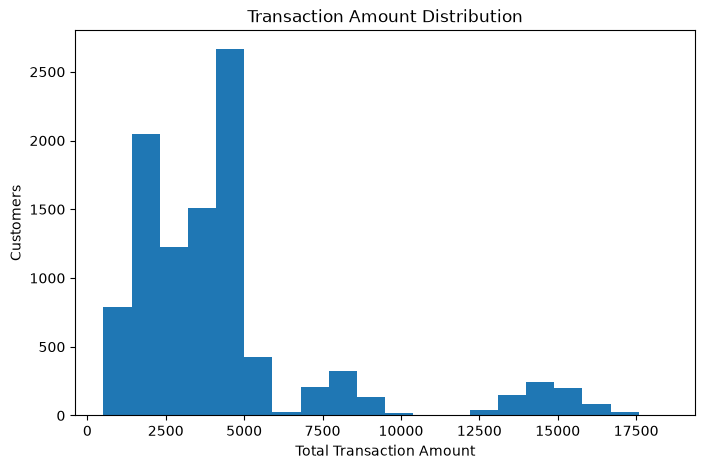

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df['Total_Trans_Amt'], bins=20)
plt.title('Transaction Amount Distribution')
plt.xlabel('Total Transaction Amount')
plt.ylabel('Customers')
plt.show()

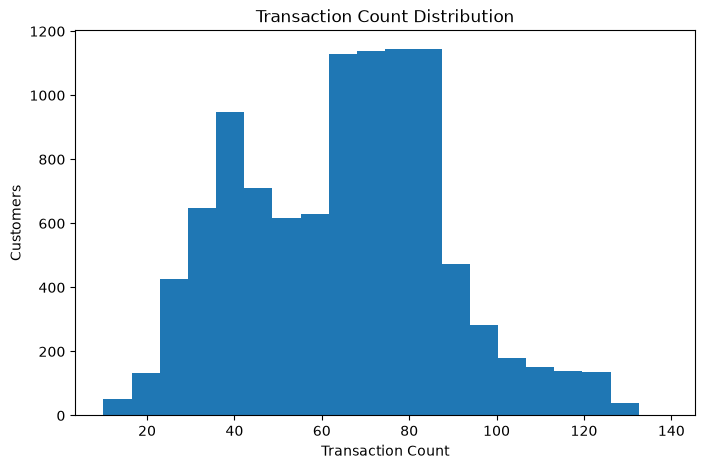

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df['Total_Trans_Ct'], bins=20)
plt.title('Transaction Count Distribution')
plt.xlabel('Transaction Count')
plt.ylabel('Customers')
plt.show()

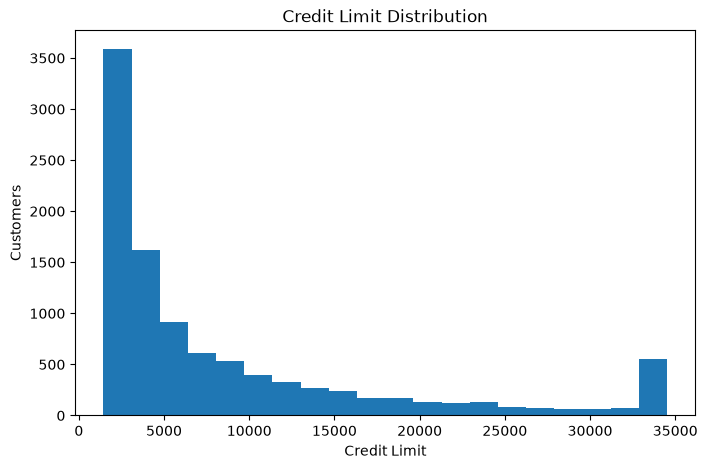

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df['Credit_Limit'], bins=20)
plt.title('Credit Limit Distribution')
plt.xlabel('Credit Limit')
plt.ylabel('Customers')
plt.show()

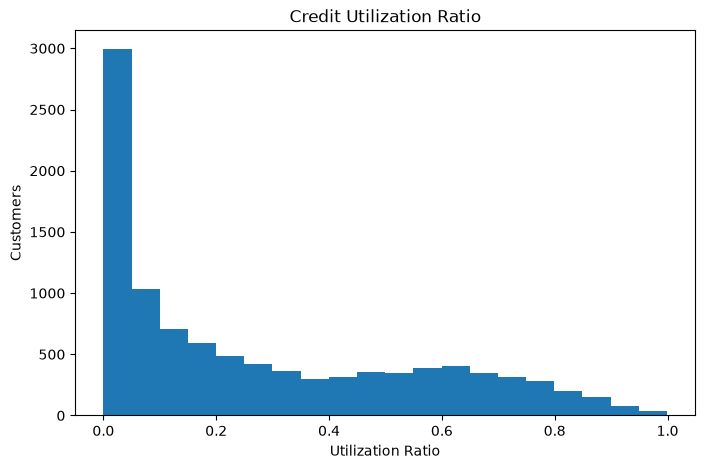

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df['Avg_Utilization_Ratio'], bins=20)
plt.title('Credit Utilization Ratio')
plt.xlabel('Utilization Ratio')
plt.ylabel('Customers')
plt.show()

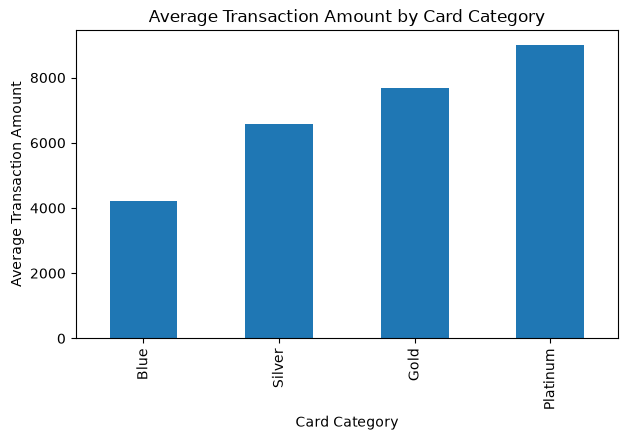

In [30]:
df.groupby('Card_Category')['Total_Trans_Amt'].mean().sort_values().plot(
    kind='bar',
    figsize=(7,4)
)
plt.title('Average Transaction Amount by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Average Transaction Amount')
plt.show()

In [31]:
df[['Customer_Age',
    'Credit_Limit',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio']].describe()

,Customer_Age,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,8631.953698,4404.086304,64.858695,0.274894
std,8.016814,9088.776650,3397.129254,23.472570,0.275691
min,26.000000,1438.300000,510.000000,10.000000,0.000000
25%,41.000000,2555.000000,2155.500000,45.000000,0.023000
50%,46.000000,4549.000000,3899.000000,67.000000,0.176000
75%,52.000000,11067.500000,4741.000000,81.000000,0.503000
max,73.000000,34516.000000,18484.000000,139.000000,0.999000


In [32]:
import pandas as pd

rfm = df[['CLIENTNUM',
          'Months_Inactive_12_mon',
          'Total_Trans_Ct',
          'Total_Trans_Amt']].copy()

# Recency Score (lower inactive months = better)
rfm['R_Score'] = pd.qcut(
    rfm['Months_Inactive_12_mon'].rank(method='first'),
    4,
    labels=[4,3,2,1]
)

# Frequency Score
rfm['F_Score'] = pd.qcut(
    rfm['Total_Trans_Ct'],
    4,
    labels=[1,2,3,4]
)

# Monetary Score
rfm['M_Score'] = pd.qcut(
    rfm['Total_Trans_Amt'],
    4,
    labels=[1,2,3,4]
)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,CLIENTNUM,Months_Inactive_12_mon,Total_Trans_Ct,Total_Trans_Amt,R_Score,F_Score,M_Score,RFM_Score
0,768805383,1,42,1144,4,1,1,411
1,818770008,1,33,1291,4,1,1,411
2,713982108,1,20,1887,4,1,1,411
3,769911858,4,20,1171,1,1,1,111
4,709106358,1,28,816,4,1,1,411


In [33]:
def segment(row):
    if row['RFM_Score'] >= '444':
        return 'Champions'
    elif row['RFM_Score'] >= '344':
        return 'Loyal Customers'
    elif row['RFM_Score'] >= '244':
        return 'Potential Loyalists'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm['Segment'].value_counts()

Segment
At Risk                4666
Potential Loyalists    2767
Loyal Customers        2276
Champions               418
Name: count, dtype: int64

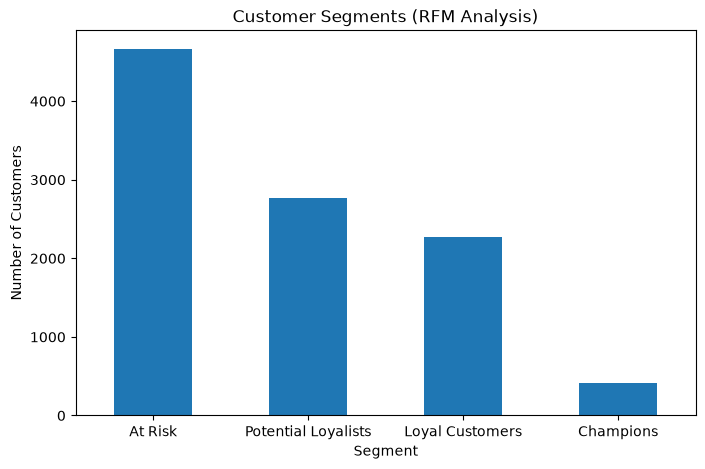

In [34]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

In [35]:
import pandas as pd

rfm = df[['CLIENTNUM',
          'Months_Inactive_12_mon',
          'Total_Trans_Ct',
          'Total_Trans_Amt']].copy()

# Recency Score (lower inactive months = better)
rfm['R_Score'] = pd.qcut(
    rfm['Months_Inactive_12_mon'].rank(method='first'),
    4,
    labels=[4,3,2,1]
)

# Frequency Score
rfm['F_Score'] = pd.qcut(
    rfm['Total_Trans_Ct'],
    4,
    labels=[1,2,3,4]
)


In [36]:
clv = df[['CLIENTNUM', 'Months_on_book', 'Total_Trans_Amt']].copy()

clv['CLV_Proxy'] = (
    clv['Total_Trans_Amt'] /
    clv['Months_on_book']
).round(2)

clv.head()

,CLIENTNUM,Months_on_book,Total_Trans_Amt,CLV_Proxy
0,768805383,39,1144,29.33
1,818770008,44,1291,29.34
2,713982108,36,1887,52.42
3,769911858,34,1171,34.44
4,709106358,21,816,38.86


In [37]:
clv['CLV_Segment'] = pd.qcut(
    clv['CLV_Proxy'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

clv.head()

,CLIENTNUM,Months_on_book,Total_Trans_Amt,CLV_Proxy,CLV_Segment
0,768805383,39,1144,29.33,Low Value
1,818770008,44,1291,29.34,Low Value
2,713982108,36,1887,52.42,Low Value
3,769911858,34,1171,34.44,Low Value
4,709106358,21,816,38.86,Low Value


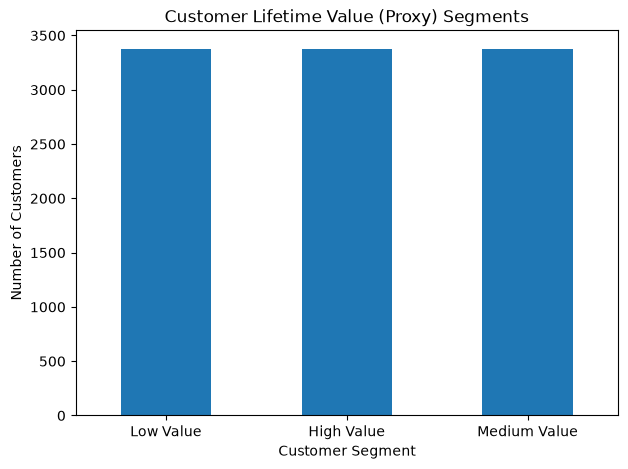

In [38]:
import matplotlib.pyplot as plt

clv['CLV_Segment'].value_counts().plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Customer Lifetime Value (Proxy) Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

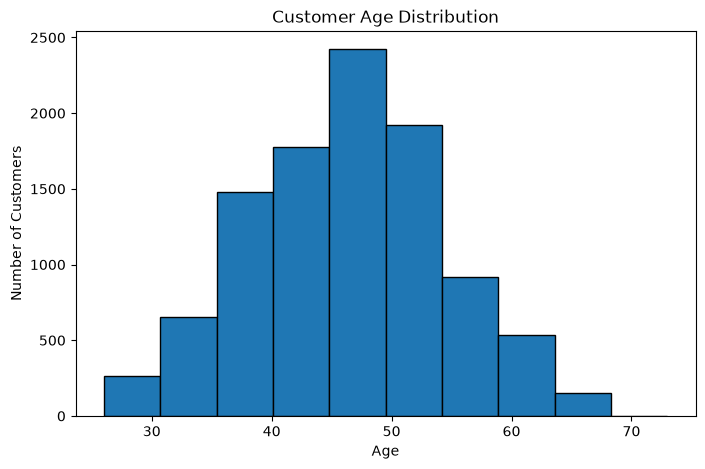

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df['Customer_Age'], bins=10, edgecolor='black')

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

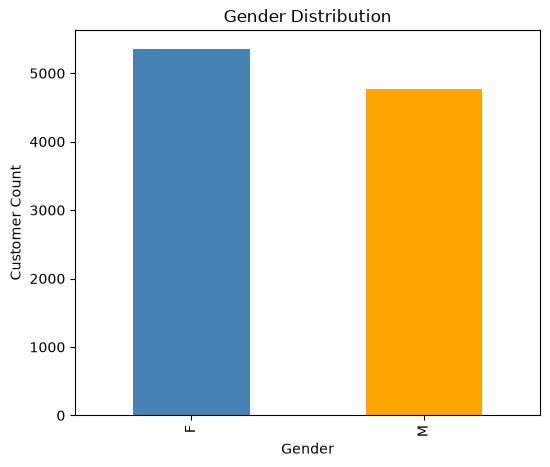

In [40]:
plt.figure(figsize=(6,5))

df['Gender'].value_counts().plot(
    kind='bar',
    color=['steelblue','orange']
)

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Customer Count')

plt.show()

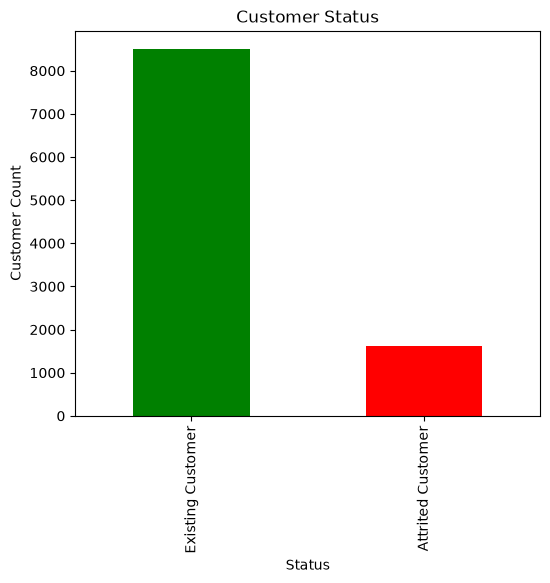

In [41]:
plt.figure(figsize=(6,5))

df['Attrition_Flag'].value_counts().plot(
    kind='bar',
    color=['green','red']
)

plt.title('Customer Status')
plt.xlabel('Status')
plt.ylabel('Customer Count')

plt.show()

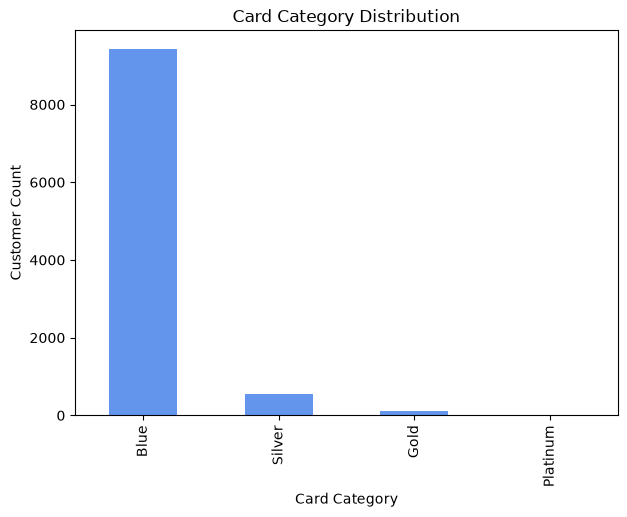

In [42]:
plt.figure(figsize=(7,5))

df['Card_Category'].value_counts().plot(
    kind='bar',
    color='cornflowerblue'
)

plt.title('Card Category Distribution')
plt.xlabel('Card Category')
plt.ylabel('Customer Count')

plt.show()

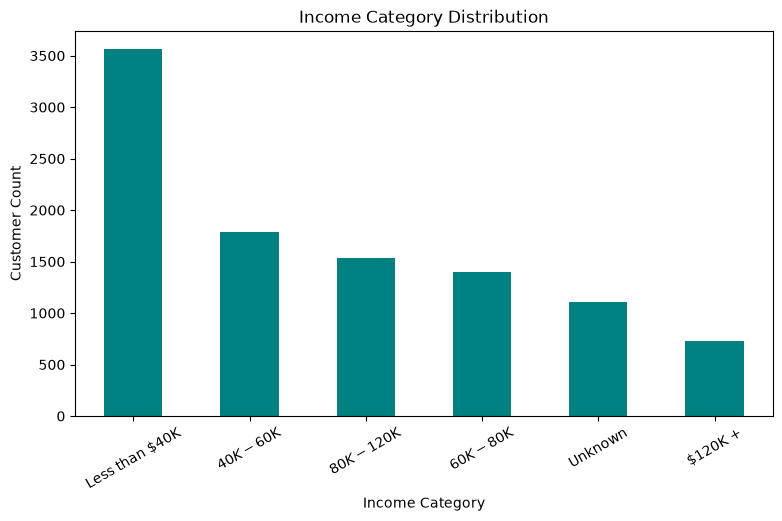

In [43]:
plt.figure(figsize=(9,5))

df['Income_Category'].value_counts().plot(
    kind='bar',
    color='teal'
)

plt.title('Income Category Distribution')
plt.xlabel('Income Category')
plt.ylabel('Customer Count')

plt.xticks(rotation=30)

plt.show()

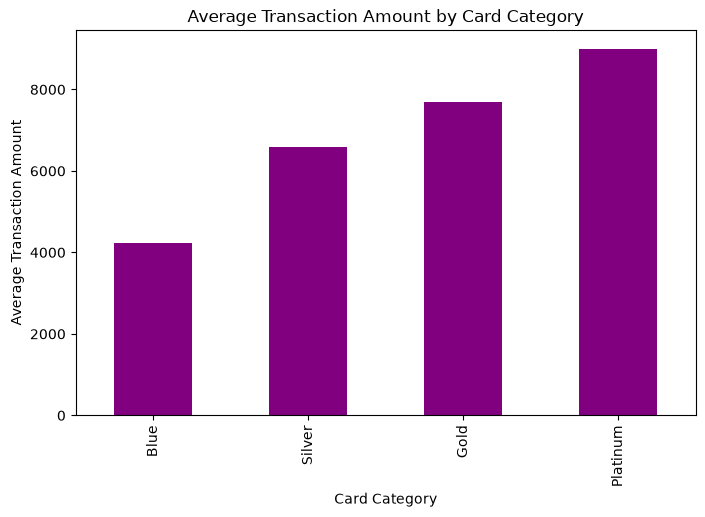

In [44]:
plt.figure(figsize=(8,5))

df.groupby('Card_Category')['Total_Trans_Amt'].mean().sort_values().plot(
    kind='bar',
    color='purple'
)

plt.title('Average Transaction Amount by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Average Transaction Amount')

plt.show()

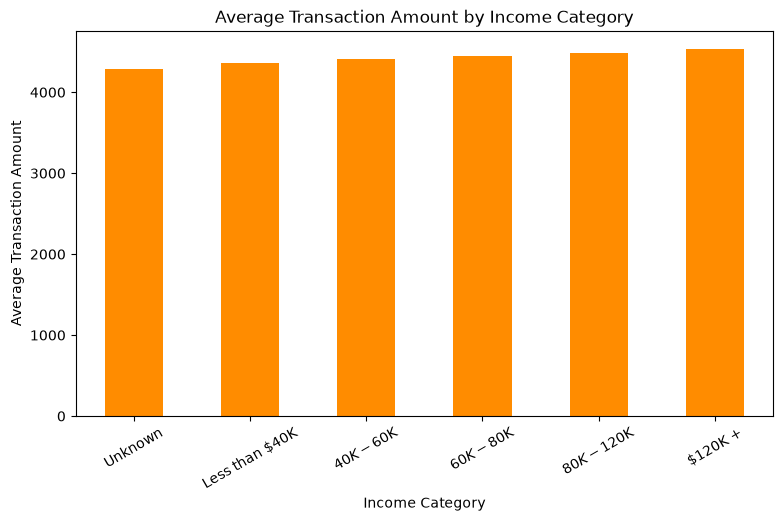

In [45]:
plt.figure(figsize=(9,5))

df.groupby('Income_Category')['Total_Trans_Amt'].mean().sort_values().plot(
    kind='bar',
    color='darkorange'
)

plt.title('Average Transaction Amount by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Average Transaction Amount')

plt.xticks(rotation=30)

plt.show()

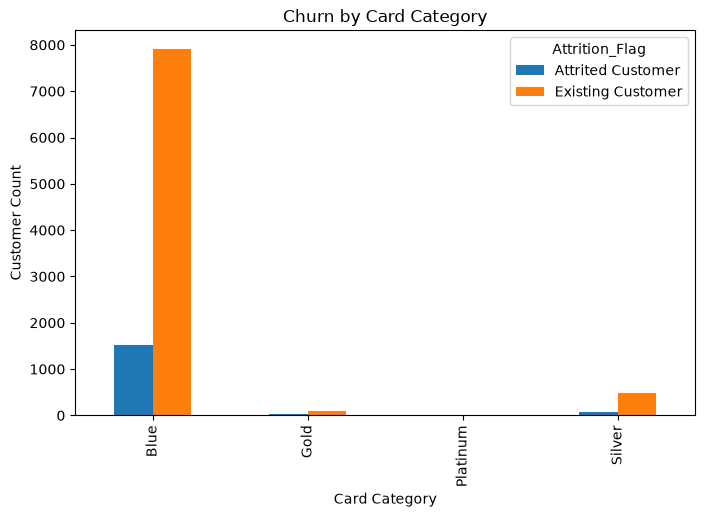

In [46]:
pd.crosstab(
    df['Card_Category'],
    df['Attrition_Flag']
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Customer Count')

plt.show()

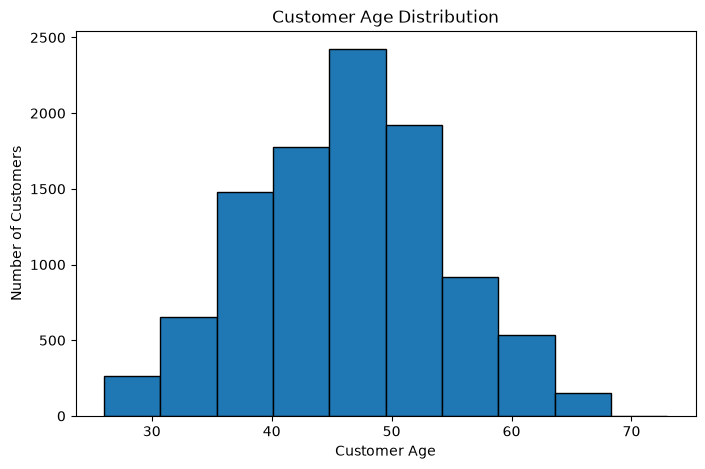

In [47]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Customer_Age'],
    bins=10,
    edgecolor='black'
)

plt.title('Customer Age Distribution')
plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')

plt.show()

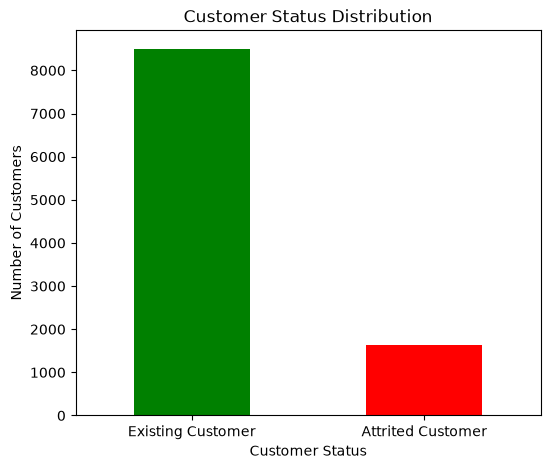

In [48]:
plt.figure(figsize=(6,5))

df['Attrition_Flag'].value_counts().plot(
    kind='bar',
    color=['green', 'red']
)

plt.title('Customer Status Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

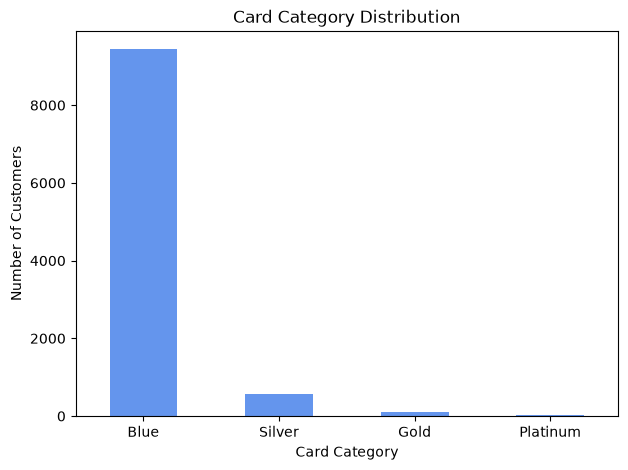

In [49]:
plt.figure(figsize=(7,5))

df['Card_Category'].value_counts().plot(
    kind='bar',
    color='cornflowerblue'
)

plt.title('Card Category Distribution')
plt.xlabel('Card Category')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

<Figure size 800x500 with 0 Axes>

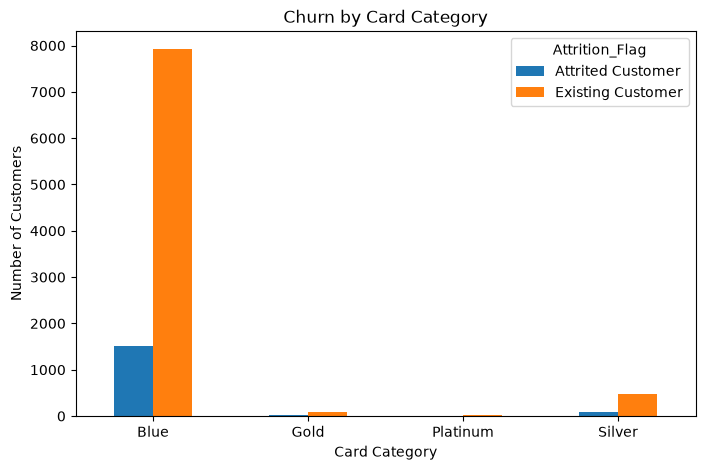

In [50]:
plt.figure(figsize=(8,5))

pd.crosstab(
    df['Card_Category'],
    df['Attrition_Flag']
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

<Figure size 800x500 with 0 Axes>

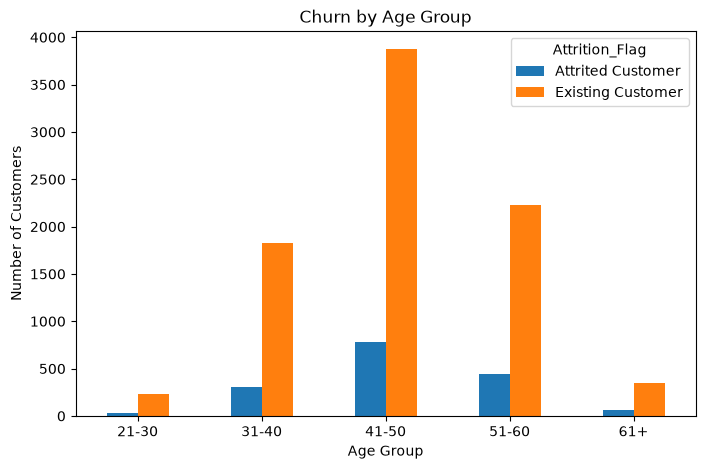

In [51]:
# Create Age Groups
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[20, 30, 40, 50, 60, 75],
    labels=['21-30', '31-40', '41-50', '51-60', '61+']
)

# Plot Churn by Age Group
plt.figure(figsize=(8,5))

pd.crosstab(
    df['Age_Group'],
    df['Attrition_Flag']
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

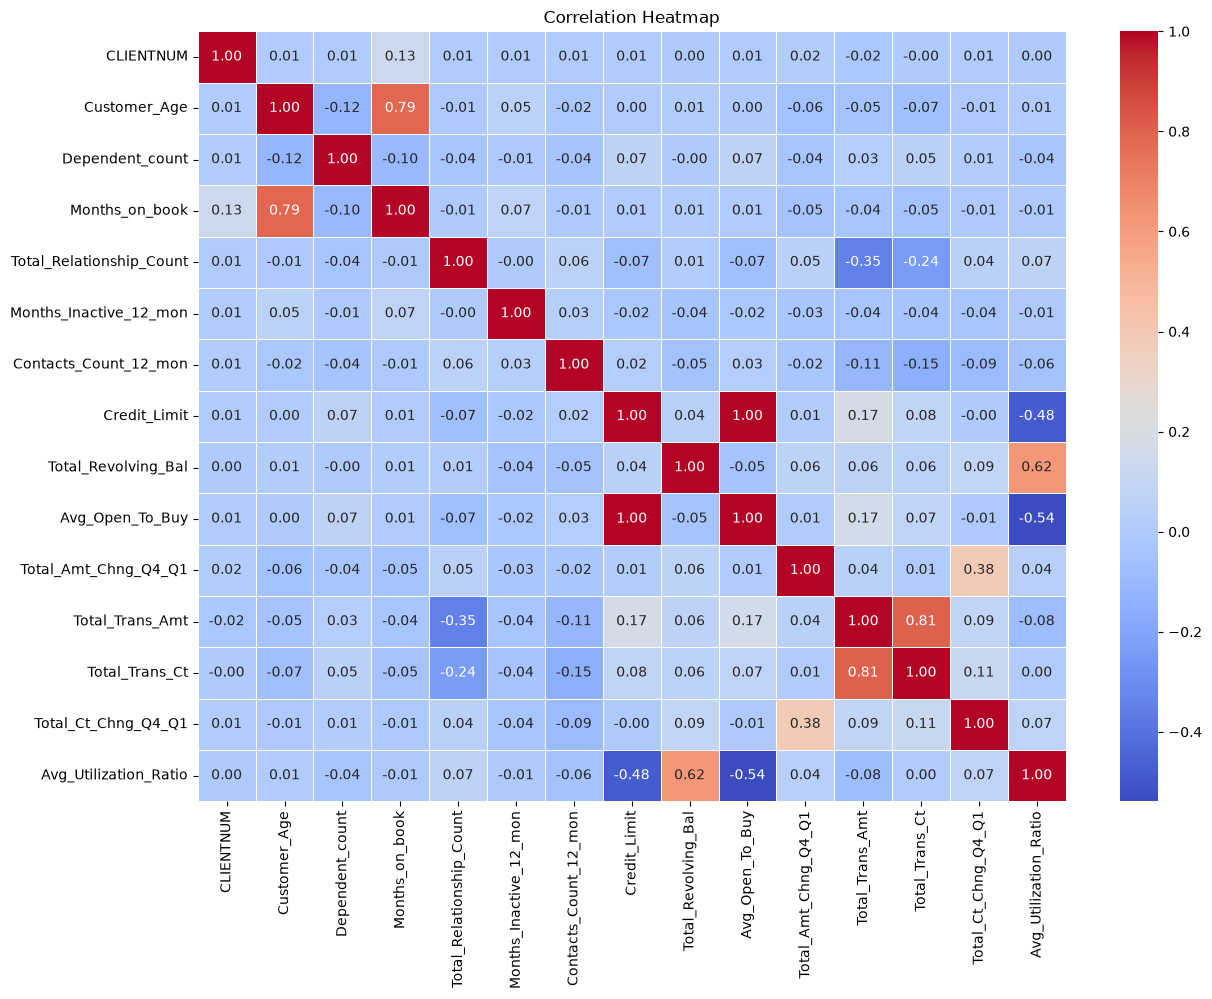

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

corr_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

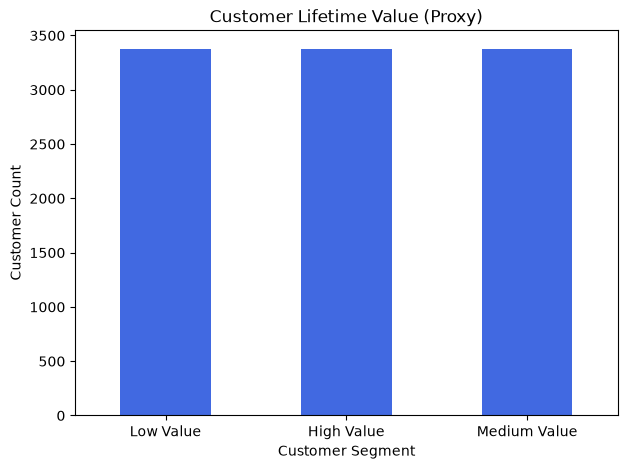

In [53]:
plt.figure(figsize=(7,5))

clv['CLV_Segment'].value_counts().plot(
    kind='bar',
    color='royalblue'
)

plt.title('Customer Lifetime Value (Proxy)')
plt.xlabel('Customer Segment')
plt.ylabel('Customer Count')

plt.xticks(rotation=0)

plt.show()

In [54]:
plt.figure(figsize=(7,5))

rfm['Segment'].value_counts().plot(
    kind='bar',
    color='mediumseagreen'
)

plt.title('RFM Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Customer Count')

plt.xticks(rotation=15)

plt.show()

KeyError: 'Segment'

<Figure size 700x500 with 0 Axes>

C:\Users\himan\AppData\Local\Temp\ipykernel_9500\4104460815.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RFM_Segment', order=order, palette='viridis')


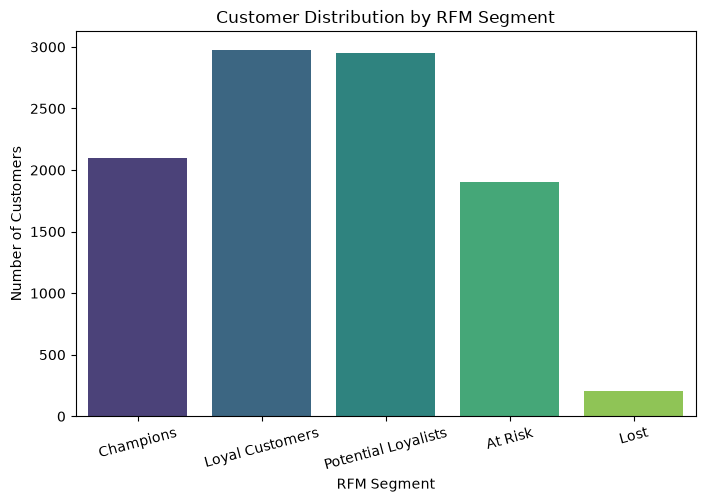

RFM_Segment
Loyal Customers        2978
Potential Loyalists    2948
Champions              2096
At Risk                1900
Lost                    205
Name: count, dtype: int64


In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- RFM Scoring (1-4 scale using quartiles) ---
df['R_Score'] = pd.qcut(df['Months_Inactive_12_mon'].rank(method='first'), 4, labels=[4,3,2,1]).astype(int)
df['F_Score'] = pd.qcut(df['Total_Trans_Ct'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['M_Score'] = pd.qcut(df['Total_Trans_Amt'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)

df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

# --- Segment customers based on total RFM score ---
def rfm_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

df['RFM_Segment'] = df['RFM_Score'].apply(rfm_segment)

# --- Bar Chart ---
plt.figure(figsize=(8,5))
order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
sns.countplot(data=df, x='RFM_Segment', order=order, palette='viridis')
plt.title('Customer Distribution by RFM Segment')
plt.xlabel('RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Check segment counts for your insight writeup ---
print(df['RFM_Segment'].value_counts())